# Health Insurance Cost Prediction 

### Project Overview
### Data Cleaning
### Exploratory Data Analysis
### Feature Engineering
### Model Training
### Model Evaluation
### Conclusion

### Project Overview


The objective of the project is to predict health insurance costs using machine learning techniques. The selected data set includes key elements such as Age, Sex, BMI, Number of Children, Smoking status and Region, all relevant factors in estimating insurance prices.

The analysis starts with data preprocessing to understand the correlations between variables, followed by Exploratary Data Analysis feature engineering, development then comparison of Linear Rgression, Polynomial Regression and Random Forest models to evaluate predictive performance.



### Data Import and Cleaning

In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df= pd.read_csv('insurance.csv')
df

# Create a background to have better visual of the data
# Format to Float to 2 decimal places
# Clean up duplicates, NA values and others

sns.set(style="whitegrid",palette='Set2', font_scale=1.5)

pd.set_option("display.float_format",lambda x :f"{x:.2f}")
df


print(df.duplicated().sum(), "Duplicate found in : ", df.shape)

df = df.drop_duplicates()

print("The duplicate has been removed : ", df.shape)

df.isna().sum().sum()
df.describe(include="all")

1 Duplicate found in :  (1338, 7)
The duplicate has been removed :  (1337, 7)


,age,sex,bmi,children,smoker,region,charges
count,1337.00,1337,1337.00,1337.00,1337,1337,1337.00
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,675,NaN,NaN,1063,364,NaN
mean,39.22,NaN,30.66,1.10,NaN,NaN,13279.12
std,14.04,NaN,6.10,1.21,NaN,NaN,12110.36
min,18.00,NaN,15.96,0.00,NaN,NaN,1121.87
25%,27.00,NaN,26.29,0.00,NaN,NaN,4746.34
50%,39.00,NaN,30.40,1.00,NaN,NaN,9386.16
75%,51.00,NaN,34.70,2.00,NaN,NaN,16657.72


### Exploratory Data Analysis

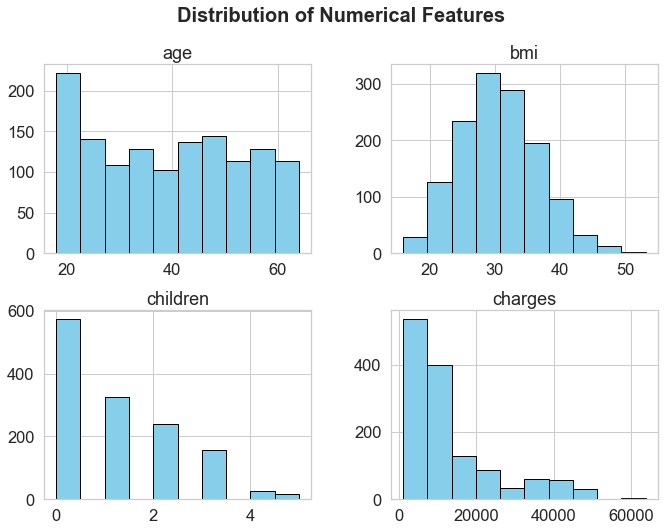

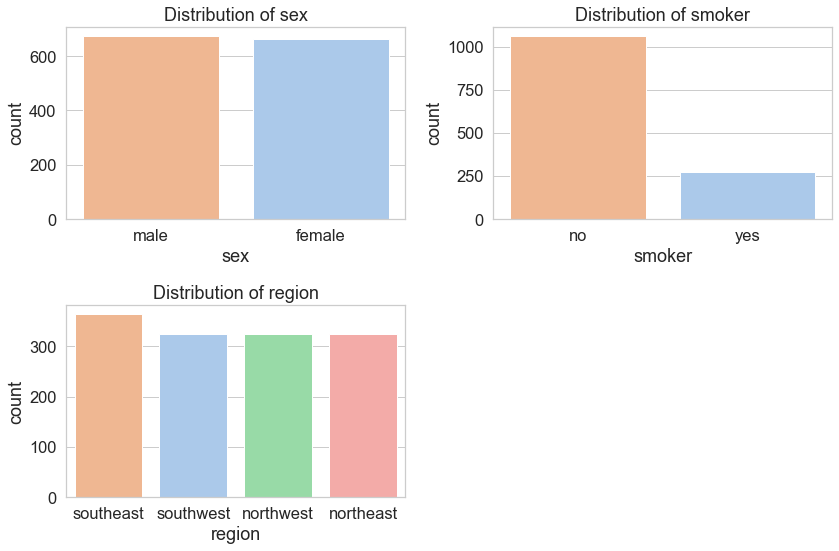

In [3]:
# Setting up a histograms to show the distribution of numercial numbers

numeric_cols =['age', 'bmi', 'children','charges']

df[numeric_cols].hist(bins=10, figsize=(11,8), color='skyblue', edgecolor = 'black')
plt.suptitle("Distribution of Numerical Features", fontsize = 20, fontweight ='bold')
plt.show()

#Creating a function to count frequency of categories' occurences 
#To visualize their distribution using countplot

cat_columns =['sex', 'smoker','region']
plt.figure(figsize=(12,8))

for i, col in enumerate (cat_columns,1):
    plt.subplot(2,2,i)
    sns.countplot(data=df,x =col, hue = col, palette ='pastel', order =df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

##### The data set is primarly composed of non-smokers, a high number of individuals between the ages of 20 to 25 years old and between 0 and 1 child. Most charges fall between approximately 5,000 and 10,000 dollars. The BMI curve appears normal, and while gender and regions are relatively balanced, there's a slight male majority as wel as prominence from southeast.  

sex     smoker
female  no         $8,762.30
        yes       $30,679.00
male    no         $8,099.70
        yes       $33,042.01
Name: charges, dtype: object


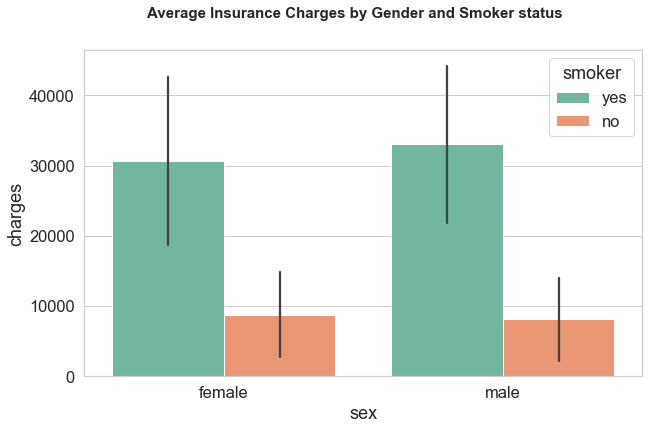

In [4]:
#Let's explore the key factors in insurance charges based on smoking status.


#Format with dollar sign

group_format = df.groupby(["sex","smoker"])["charges"].mean().round(2)
print(group_format.apply(lambda x :f'${x:,.2f}'))

plt.figure(figsize=(10,6))
sns.barplot(data=df, x="sex", y="charges", hue="smoker", estimator = np.mean, errorbar = "sd")
plt.suptitle("Average Insurance Charges by Gender and Smoker status", fontsize = 15, fontweight='bold')
plt.show()


In [5]:
#Let's add the region factor to our analysis with smoker status 

pivot_table = pd.pivot_table(df, values ="charges", index ="region", columns = "smoker", aggfunc = np.mean)
pivot_table.style.format("${:,.2f}")

smoker,no,yes
region,,
northeast,"$9,165.53","$29,673.54"
northwest,"$8,582.47","$30,192.00"
southeast,"$8,032.22","$34,845.00"
southwest,"$8,019.28","$32,269.06"


##### While it is expected for smokers to be charged significantly higher than non-smokers, the regions seem to somewhat influence insurance charges at first glance. The data suggests south region non-smokers are, on average, charged slightly less than individuals living north while it is the opposite for smokers. Smokers are on average charged higher in the South compared to Northern regions.

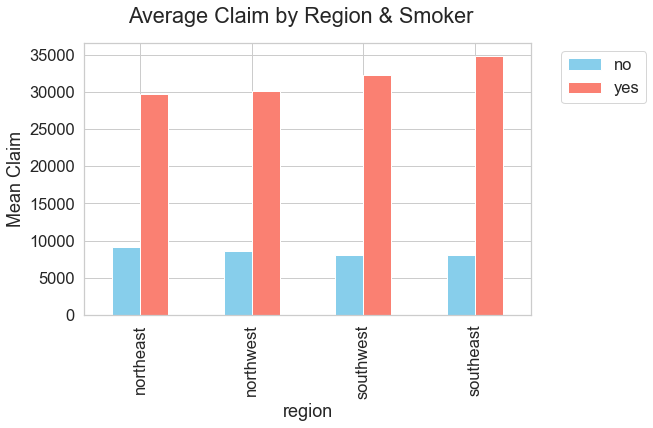

In [6]:
pivot_region_smoker = df.groupby(["region", "smoker"])["charges"].mean().unstack()
pivot_region_smoker.sort_values(by = "yes").plot(kind="bar", figsize=(8,5), color =["skyblue","salmon"])
plt.legend(bbox_to_anchor=(1.05,1), loc = "upper left")
plt.suptitle("Average Claim by Region & Smoker")
plt.ylabel ("Mean Claim")
plt.show()

Significant relationship between age and charges 
 corr = 0.2983 and p_value =0.0000

Significant relationship between bmi and charges 
 corr = 0.1984 and p_value =0.0000

Significant relationship between sex and charges 
 corr = 0.0580 and p_value =0.0338

Significant relationship between smoker and charges 
 corr = 0.7872 and p_value =0.0000

Not a significant relationship between region and charges
Significant relationship between children and charges 
 corr = 0.0674 and p_value =0.0137


Correlation between all variable relative to charges :
            age   sex  bmi  children  smoker  region  charges
age       1.00 -0.02 0.11      0.04   -0.03    0.00     0.30
sex      -0.02  1.00 0.05      0.02    0.08    0.00     0.06
bmi       0.11  0.05 1.00      0.01    0.00    0.16     0.20
children  0.04  0.02 0.01      1.00    0.01    0.02     0.07
smoker   -0.03  0.08 0.00      0.01    1.00   -0.00     0.79
region    0.00  0.00 0.16      0.02   -0.00    1.00    -0.01
charges   0.30  0.06

Text(0.5, 0.98, 'Heat Map correlation between each variables')

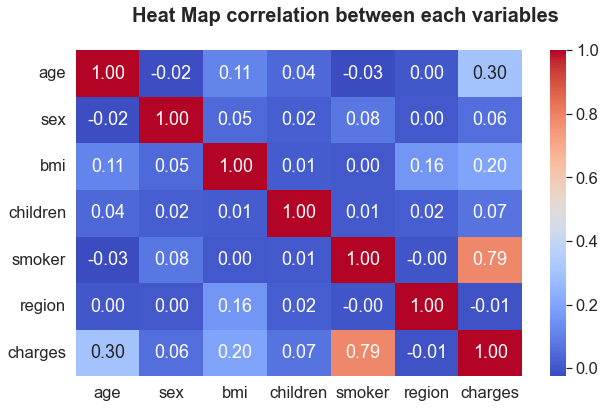

In [7]:
from scipy.stats import pearsonr

#Let's check for Statistical Significance using Pearson Correlation Test (p-value)
df_corr= df.copy()
df_corr['smoker'] = (df['smoker']=='yes').astype(int)
df_corr['sex']= (df['sex']=='male').astype(int)
df_corr['region']= df['region'].map({'northeast':0, 'northwest':1, 'southeast':2,'southwest':3})

test = ['age','bmi','sex','smoker','region','children']

for col in test:
    corr, p_value = pearsonr(df_corr[col], df_corr['charges'])
    if p_value < 0.05:
        print(f"Significant relationship between {col} and charges \n corr = {corr:.4f} and p_value ={p_value:.4f}\n")
    else:
        print(f"Not a significant relationship between {col} and charges")
    
print("\nCorrelation between all variable relative to charges :\n",df_corr.corr())

plt.figure(figsize=(10,6))

sns.heatmap(df_corr.corr(), annot= True, cmap= "coolwarm", fmt=".2f")
plt.suptitle('Heat Map correlation between each variables', fontsize = 20, fontweight= 'bold')

##### The Pearson correlation test and the Heatmap provide a clear understanding that smoking status is the most prevalent factor in insurance pricing estimation with a strong correlation coefficent of 0.79 . It is weakly followed by Age and BMI with 0.3 and 0.2 respectively. In addition, the significance test refuted the assumption that regions did influence insurance prices, as well as sex and children. 

Text(0.5, 0.98, 'Insurance Charges vs Age by Smoker and Gender status')

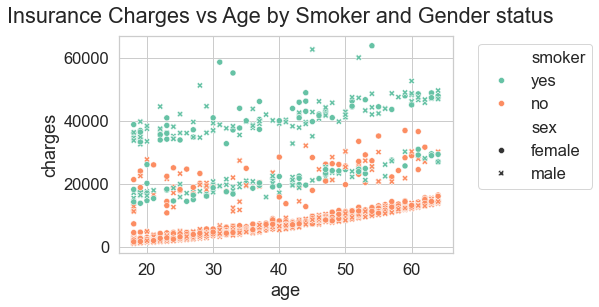

In [8]:
#Continuation of Exploratory analysis with smoker, gender and charges
#Further confirming that gender has almost no influence on pricing 
#but mostly age and smoking status

sns.scatterplot(data=df, x="age", y="charges", hue ="smoker",style ="sex", alpha=1)
plt.legend(bbox_to_anchor=(1.05,1), loc ="upper left")
plt.suptitle("Insurance Charges vs Age by Smoker and Gender status")

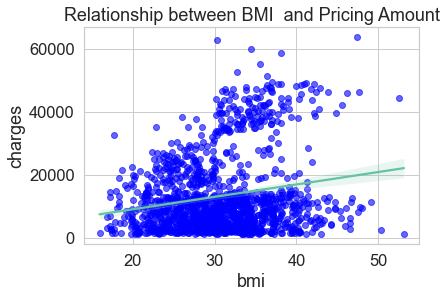

Obesity           399
Overweight        380
Morbidly Obese    316
Healthy           221
Underweight        21
Name: bmi_category, dtype: int64


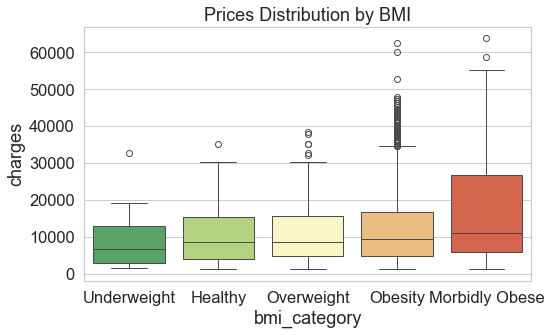

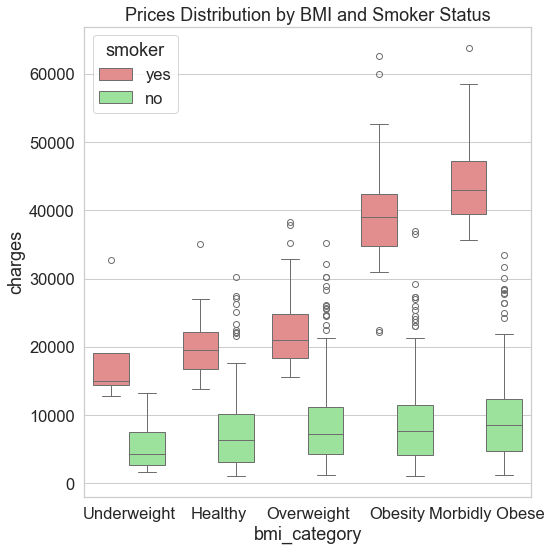

In [9]:
#Exploratory Analysis on BMI and pricing

sns.regplot(data=df, x ="bmi", y="charges", scatter_kws={"alpha":0.6, "color": 'blue'})
plt.title ('Relationship between BMI  and Pricing Amount')
plt.show()

df["bmi_category"]= pd.cut(df["bmi"], bins =[0, 18.5, 24.9, 29.9, 35, 100], labels =["Underweight", "Healthy","Overweight","Obesity", "Morbidly Obese"])
print(df["bmi_category"].value_counts())

#Box plot shows the influence of BMI on Insurance 
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="bmi_category", y="charges", hue="bmi_category", palette='RdYlGn_r')
plt.title("Prices Distribution by BMI")
plt.tight_layout()

#This boxplot shows the effect of Smoking and BMI on pricing
plt.figure(figsize=(8,8))
sns.boxplot(data=df, x="bmi_category", y="charges", hue="smoker", palette =["lightcoral","lightgreen"])
plt.title("Prices Distribution by BMI and Smoker Status")
plt.tight_layout()


###### The regression plot showcases a heavy concentration of observations under 10,000 dollars in charges across a BMI range of 20 to approximately 40 which emcompasses healthy to morbidly obese. Furthermore, we can notice 2 distinct groups with higher charges with BMI range of 15-30 as well as 30-45. This observation reconfirms that BMI alone is not a strong predictor of cost. The difference is likely due to smoking status shown in the Pricing by distribution by BMI and Smoker box plot, where smokers consistently incur higher charges. 

In [10]:
#Exploratory Analysis on Age 

df["age_group"]=pd.cut(df["age"], bins = [1,18,30,45,60,100], labels=["<18", "18-30", "31-45","46-60", "60+"])
df

,age,sex,bmi,children,smoker,region,charges,bmi_category,age_group
0,19,female,27.90,0,yes,southwest,16884.92,Overweight,18-30
1,18,male,33.77,1,no,southeast,1725.55,Obesity,<18
2,28,male,33.00,3,no,southeast,4449.46,Obesity,18-30
3,33,male,22.70,0,no,northwest,21984.47,Healthy,31-45
4,32,male,28.88,0,no,northwest,3866.86,Overweight,31-45
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.97,3,no,northwest,10600.55,Obesity,46-60
1334,18,female,31.92,0,no,northeast,2205.98,Obesity,<18
1335,18,female,36.85,0,no,southeast,1629.83,Morbidly Obese,<18
1336,21,female,25.80,0,no,southwest,2007.94,Overweight,18-30


46-60    409
31-45    394
18-30    374
60+       91
<18       69
Name: age_group, dtype: int64


<AxesSubplot:xlabel='age_group', ylabel='charges'>

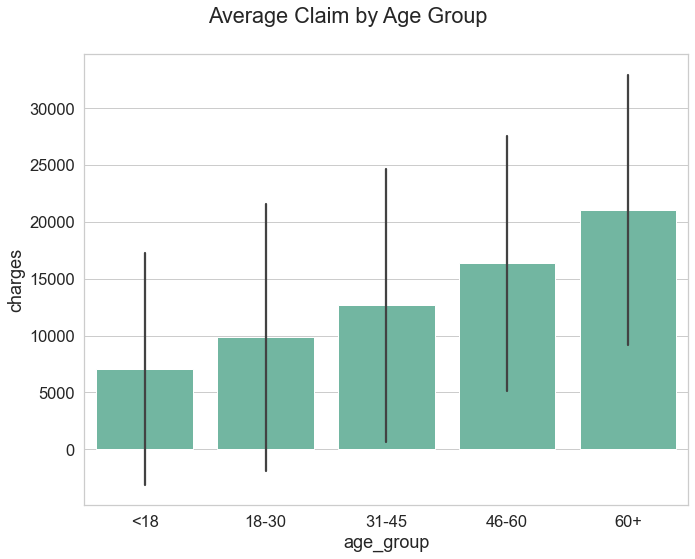

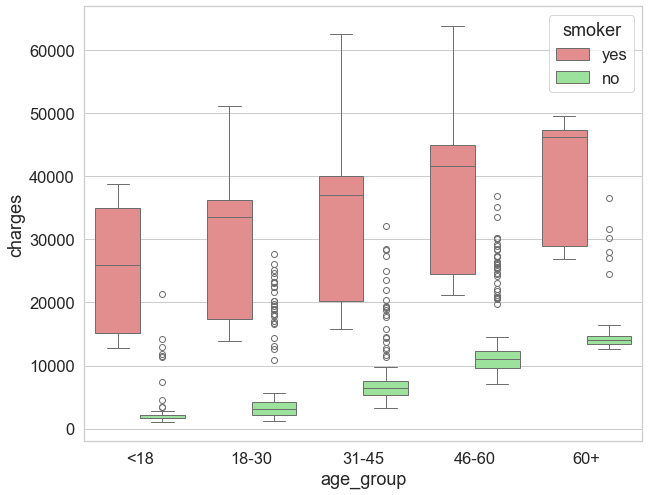

In [35]:
print(df["age_group"].value_counts())

plt.figure(figsize=(10,8))
sns.barplot(data=df, x="age_group", y="charges", estimator=np.mean , errorbar="sd")
plt.suptitle("Average Claim by Age Group")
plt.tight_layout()
plt.figure(figsize=(10,8))
sns.boxplot(data=df,x="age_group", y="charges", hue="smoker", palette=['lightcoral','lightgreen'])

##### Naturally, Age has a moderate positive correlation to insurance charges factor. However, smoking status remains by far the strongest influence, accounting for majority of cost variation across all demographics.


<AxesSubplot:title={'center':'Price Distribution by Number of Children'}, xlabel='children,sex'>

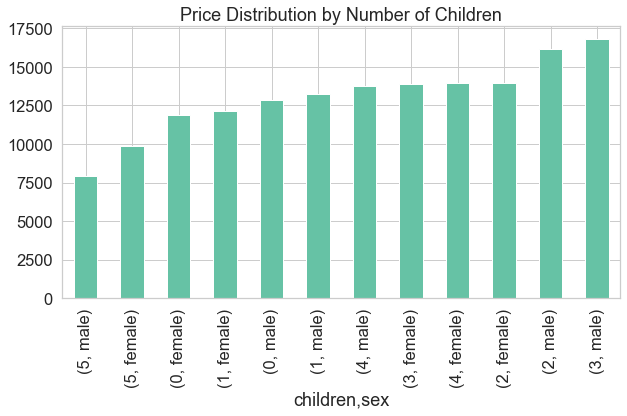

In [13]:
plt.title ("Price Distribution by Number of Children")
children = df.groupby(["children","sex"])["charges"].mean()
children.sort_values().plot(kind="bar", figsize = (10,5))

In [14]:
# Cretate the rate of smokers per region
region_stats = df.groupby("region").agg(
    smoker_rate =("smoker", lambda x :(x=="yes").mean()*100),
    mean_claim =("charges",np.mean)).reset_index()
region_stats

,region,smoker_rate,mean_claim
0,northeast,20.68,13406.38
1,northwest,17.90,12450.84
2,southeast,25.00,14735.41
3,southwest,17.85,12346.94


The average claim in northeast is $13,406.38 with around 20.68% of Smokers
The average claim in northwest is $12,450.84 with around 17.90% of Smokers
The average claim in southeast is $14,735.41 with around 25.00% of Smokers
The average claim in southwest is $12,346.94 with around 17.85% of Smokers


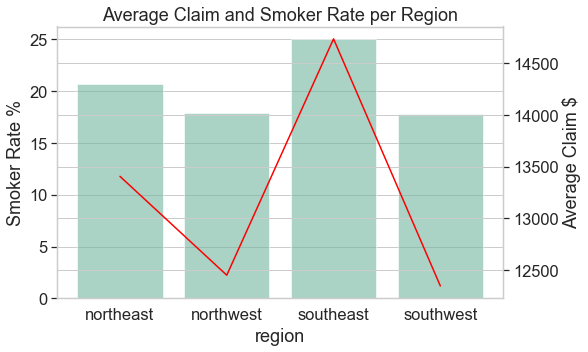

In [15]:
fig, ax1= plt.subplots(figsize=(8,5))
sns.barplot(data = region_stats, x="region", y="smoker_rate", ax=ax1, alpha=0.6)
#Creates a second Y-axis and a trend line
ax2=ax1.twinx()
sns.lineplot(data=region_stats, x ="region", y="mean_claim", ax=ax2, color="red")
ax1.set_ylabel("Smoker Rate %")
ax2.set_ylabel("Average Claim $")
plt.title ("Average Claim and Smoker Rate per Region")
for i, row in region_stats.iterrows():
    print(f"The average claim in {row['region']} is ${row['mean_claim']:,.2f} with around {row['smoker_rate']:.2f}% of Smokers")


In [16]:
#Importing to process data with SckitLearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib
from sklearn.ensemble import RandomForestRegressor

In [17]:

#Transform data into numbers for Machine Learning by using LabelEncoders and create pkl files that will be used later 
df.columns
#Copy data to avoid errors and keep original
X= df[["age", "sex","bmi","children","smoker","region"]].copy()
y=df["charges"].copy()
cat_columns=["sex", "bmi", "smoker","region"]
label_encoders={}
for col in cat_columns:
    le = LabelEncoder()
    X.loc[:,col] = le.fit_transform(X[col])
    label_encoders[col] = le
    
    joblib.dump(le, f"label_encoders{col}.pkl")
label_encoders

{'sex': LabelEncoder(),
 'bmi': LabelEncoder(),
 'smoker': LabelEncoder(),
 'region': LabelEncoder()}

In [18]:
# Let's compare Linear Regression and Random Forest Models to identify the most effective model.
#The Data will be split in order to train and test the models in a 4:1 ratio.
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2)
num_cols=["age","bmi","children"]
scaler=StandardScaler()
model_rf=RandomForestRegressor(random_state=42)

#Copied X data into X_train and X_test avoid errors 

X_train=X_train.copy()
X_test=X_test.copy()

#Assigning value for Random Forest
model_rf.fit(X_train, y_train)
#y_predict_rf=model_rf.predict(X_test)

#Scaling for Linear Regression
X_train[num_cols]=scaler.fit_transform(X_train[num_cols])
X_test[num_cols]=scaler.transform(X_test[num_cols])


In [19]:
joblib.dump(scaler,"scaler.pkl")


['scaler.pkl']

In [20]:
print(f"This is the first 10 rows of the 5 columns from our Linear Regression training data.\n{X_train.head(10)}")
print(f"\nAnd its corresponding charges \n {y_train.head(10)}")


This is the first 10 rows of the 5 columns from our Linear Regression training data.
       age  sex   bmi  children  smoker  region
1202 -1.22    1  0.29     -0.90       0       1
1149  0.20    1  0.65     -0.90       0       3
1213  0.91    0  0.51      0.76       0       3
1062  1.40    1  1.66     -0.07       1       2
337   1.62    1 -0.57     -0.07       0       1
689  -0.86    1  0.11     -0.07       1       2
889   1.26    1  0.57     -0.07       0       1
84   -0.15    0  0.77      0.76       1       3
676   1.12    0  1.64      1.59       0       2
421   1.55    1  0.95     -0.90       1       2

And its corresponding charges 
 1202    2055.32
1149    5979.73
1213   10806.84
1062   48970.25
337    13937.67
689    34806.47
889    11945.13
84     39836.52
676    12485.80
421    46599.11
Name: charges, dtype: float64


In [21]:
#Ensuring that the data has been allocated in its entirety, originally we had 1337 rows and 6 columns. 
#By allocating 80% to training data we should have 1069 rows for training and 268 for testing

print(f"Training data: X :{X_train.shape} and Y : {y_train.shape}")
print(f"Testing data: X:{X_test.shape} and Y: {y_test.shape}")

Training data: X :(1069, 6) and Y : (1069,)
Testing data: X:(268, 6) and Y: (268,)


In [22]:
#Let's import the rest of the libraries needed
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, cross_val_score

In [23]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    y_predict=model.predict(X_test)
    r2=r2_score(y_test, y_predict)
    MAE= mean_absolute_error(y_test,y_predict)
    RMSE=np.sqrt(mean_squared_error(y_test,y_predict))
    return {"R2": r2, "Mean Abs Err": MAE, "Root M.Sqrt Err": RMSE}

In [24]:
#Linear Regression model construction
lr=LinearRegression()
lr.fit(X_train,y_train)
results={}
results["Linear Regression"]=evaluate_model(lr, X_train, X_test,y_train,y_test)
print("Linear Regression Model trained")


Linear Regression Model trained


In [25]:
best_polynomial_model= None
best_polynomial_score= -np.inf

for degree in [2,3]:
    poly=PolynomialFeatures(degree = degree)
    X_train_poly=poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    poly_lr=LinearRegression()
    poly_lr.fit(X_train_poly, y_train)
    
    score =poly_lr.score(X_test_poly,y_test)
    
    if score > best_polynomial_score:
        best_polynomial_score = score
        best_polynomial_model=(degree, poly,poly_lr)
degree, poly, poly_lr = best_polynomial_model
results[f"Polynomial Regression (deg={degree})"]=evaluate_model(poly_lr, poly.fit_transform(X_train), poly.transform(X_test), y_train, y_test)
print("Polynomials Regression models are now trained")

Polynomials Regression models are now trained


In [26]:
rf = RandomForestRegressor()
rf_params= {
    "n_estimators": [300,400],
    "max_depth":[None,30,40],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}

rf_grid=GridSearchCV(rf,rf_params,cv=3, scoring="r2", n_jobs=-1, verbose=1)
rf_grid.fit(X_train,y_train)
best_rf = rf_grid.best_estimator_
results["Random Forest"]=evaluate_model(best_rf, X_train,X_test,y_train,y_test)
print("Random Forest Training is completes, best parameters are\n", rf_grid.best_estimator_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Random Forest Training is completes, best parameters are
 RandomForestRegressor(min_samples_leaf=2, min_samples_split=5, n_estimators=400)


In [27]:
results_df=pd.DataFrame(results).T.sort_values(by="R2", ascending =False)
results_df

,R2,Mean Abs Err,Root M.Sqrt Err
Random Forest,0.87,2506.92,4537.61
Polynomial Regression (deg=2),0.86,2882.58,4619.14
Linear Regression,0.76,4201.53,6142.76


In [28]:
#The trained models will be saved in a pickle for future usage.
print("The Best Model is :\n", results_df[results_df["R2"]==results_df["R2"].max()])
joblib.dump(best_rf, "Best Model Random Forest_model.pkl")


The Best Model is :
                 R2  Mean Abs Err  Root M.Sqrt Err
Random Forest 0.87       2506.92          4537.61


['Best Model Random Forest_model.pkl']